# Explaining RL GRPO 

The goal is to walk through the Group Relative Policy Optimization (GRPO) algorithm approach to reinforcement learning (RL). GRPO was famously introduced by [DeepSeek](https://arxiv.org/pdf/2402.03300) and has been one of the backbones for reasoning models. GRPO is a variant of Proximal Policy Optimization (PPO) but, contrary to PPO, it completely eliminates the need for a separate critic (value) model. GRPO does this by generating multiple responses (group) and uses those responses to calculate advantage without a separate, heavy value model.

We'll focus on applying GRPO not to an LLM, but instead to a simple number sorting model. By still having a model that generates the next token using logits, we can see how GRPO works while having a tractable policy, aka model. 

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import copy

## Data Prep

For our model, we will want to take in a list of integers and the model's goal is to learn how to sort them in descending order. E.g. input of `[0,2,1]` should output as `[2,1,0]`.  We'll start by randomly generating a set of inputs. You'll notice that we're okay with repeatitive values as in a real examples, tokens can repeat.  

In [2]:
torch.manual_seed(14)
vocab_size = 6
embedding_dim = 8
prompt_length = response_length = 5
batch = 2

In [3]:
prompt_test = torch.randint(0, vocab_size, (batch, prompt_length))
prompt_test.shape, prompt_test

(torch.Size([2, 5]),
 tensor([[3, 0, 4, 2, 3],
         [1, 2, 2, 2, 4]]))

## Policy (aka Model)

Now we'll create a simple model for our task.  If we were using an LLM this would be the actual LLM. In the RL world, this is the "Policy" that we're learning. For our task, we'll build a simple non-autoregressive encoder-decoder. The encoder embeds each prompt token, adds positional embeddings, passes them through a linear layer, and then sums across the sequence to compress the entire prompt into a single fixed-size vector. The decoder takes that single vector, broadcasts it across every response position, adds response-position embeddings so each slot knows where it sits, and projects to vocab logits. 

With our model, response length output tokens are predicted in one parallel forward pass rather than one-at-a-time.   

In [4]:
class Model(nn.Module):
    def __init__(self, vocab_size, embd_dim, prompt_len, response_len):
        super().__init__()
        self.response_len = response_len
        
        self.embedding = nn.Embedding(vocab_size, embd_dim)
        self.prompt_pos_embedding = nn.Embedding(prompt_len, embd_dim)
        self.response_pos_embedding = nn.Embedding(response_len, embd_dim)
        self.encoder = nn.Linear(embd_dim, embd_dim)
        self.decoder = nn.Linear(embd_dim, embd_dim)
        self.output = nn.Linear(embd_dim, vocab_size)
        
    def forward(self, prompts):
        batch_size, prompt_len = prompts.shape
        
        # generate positions representations for input and output
        prompt_positions = torch.arange(prompt_len)
        response_positions = torch.arange(self.response_len)

        embeddings = self.embedding(prompts)
        embeddings =  embeddings + self.prompt_pos_embedding(prompt_positions)            
        encoded = self.encoder(embeddings).sum(dim=1)
        
        resp_position_embed = self.response_pos_embedding(response_positions).unsqueeze(0)
        decoded = self.decoder(encoded).unsqueeze(1)  
        decoded = decoded + resp_position_embed
        logits = self.output(decoded)
        return logits


## Step by Step First Pass
Our first walk through will go through step by step what a single pass through an RL loop would be.  This is the same as the "Algorithm 1: Iterative Group Relative Policy Optimization" in the GRPO paper.  We wil show: 
1. caching of the policy so that we have a reference to act as "reference log probabilities" to compute the KL (Kullback-Leibler) penalty
2. sampling a set of responses for our prompts
3. calcualting the rewards and advantage. The advantage is the relative signal  calculated as the reward minus some baseline with the goal of indicating more clearly if the generated response is better or worse than expected. Positive advantages pushe probability up, and drive the gradient to reinforce those pathways while negative values pusht he model to weaken those pathways. 
4. based on the responses calculating reference log probabilities based on the reference policy
5. based on the responses calculating an initial "old" log probability based on the policy.  Note that we update the reference policy only every N epochs so the ref logprobs and the old log probs will diverge between the those epochs. 
6. For every N steps in an "epoch" we
    1. calculate the current step logprobs using the current policy
    2. calculate the loss using the logprobs, deltas.
    3. add the kl penalty to the loss using the comparison of the logprobs and the reference log probs
    4. update the policy (driven by the delta, logprobs, and kl penalty)


We will add our own wrinkle on this as we go through it showing some different ways to calculate rewards, advantage, and loss.  While ultimately we'll pick the ones closest to GRPO for the final example, we want to add a few of these in to play with different ideas we've seen. 

In [5]:
records = []
ref_log_probs = None
ref_model = None
old_log_probs = None
lossi = []
rewardi = []

### Policy Initiailzation
We'll start by initializing the policy and our optimizer to help with stepping through training.  The Adam optimizer allows us to update the policy's trainable parameters updates them using Adam's adaptive per-parameter learning rates (scaled by lr) based on the gradients populated by loss.backward(). This is a bit different than a typical training run where you'd also pair a LR scheduler.   

In [6]:
lr = 1e-3
policy_model = Model(vocab_size=vocab_size, embd_dim=10, prompt_len=prompt_length, response_len=response_length)
optimizer = torch.optim.Adam(policy_model.parameters(), lr=lr)

### KL: Ref policy copy

Our next step is to make a copy of the policy that isn't updated as frequently for us to calculate the KL penalty. The KL penalty's job is to stop the policy from drifting too far from a trusted distribution.  This distribution is often the pretrained or supervised model you started with. If we compared the current policy against itself, KL would always be zero and the penalty would do nothing. If we compared only against the previous step's model, we'd drift but slowly since the ref policy would drift along with the main policy.
In practice, by freezing a copy (and only refreshing it occasionally, or never, depending on the setup), we get a stable reference point: the KL term measures how much the live policy has diverged from that anchor and pulls it back, which keeps reward-hacking and mode collapse in check while still letting the policy improve between refreshes. 

In our example we'll use the the raw initialized policy. Here though we'll be a bit different from an LLM style usage as we'll allow the ref policy to drift since we've initialized a random set of noise.  

In [7]:
ref_policy = copy.deepcopy(policy_model)

### Generate Responses

Now we're ready to generate responses.  As a reminder, our test has a dimension of `[4, 5]` and we have a vocab size of 6.  Our model outputs logits, which is a pseudo-probability of each token for each position. After we generate them we'll also remove the batch dimension to make them easier to work with. A final step is to turn the output into probabilities.  We do this by taking the softmax using: 
$$
p_i = \frac{e^{z_i}}{\sum_{j=1}^{V} e^{z_j}}
$$
where $z$ is the logit vector along the last dim and $V$ is its size (e.g. vocab_size). This will now allow us to do sampling from the probabilities to generate an output from the distribution. 

In [8]:
logits = policy_model(prompt_test)
logits.shape, logits

(torch.Size([2, 5, 6]),
 tensor([[[-1.1137,  0.2320, -0.9153, -1.2998,  0.8457, -1.2956],
          [-0.5200, -0.6550,  0.7312,  0.2488, -0.5351, -2.1397],
          [-0.7925, -0.3202, -0.2491, -0.2959,  0.8456, -0.7270],
          [-0.8079, -0.3992, -0.0129,  0.1981,  0.0600, -0.7187],
          [-0.2375, -0.5434, -0.6405, -0.2932,  0.4465, -0.1970]],
 
         [[-0.8538,  0.0724, -0.9676, -1.3099,  1.0302, -1.1925],
          [-0.2600, -0.8146,  0.6790,  0.2387, -0.3505, -2.0366],
          [-0.5325, -0.4798, -0.3014, -0.3060,  1.0302, -0.6239],
          [-0.5480, -0.5588, -0.0652,  0.1880,  0.2445, -0.6156],
          [ 0.0225, -0.7030, -0.6927, -0.3033,  0.6310, -0.0940]]],
        grad_fn=<ViewBackward0>))

In [9]:
logits = logits.reshape(-1, logits.size(-1))
logits.shape, logits

(torch.Size([10, 6]),
 tensor([[-1.1137,  0.2320, -0.9153, -1.2998,  0.8457, -1.2956],
         [-0.5200, -0.6550,  0.7312,  0.2488, -0.5351, -2.1397],
         [-0.7925, -0.3202, -0.2491, -0.2959,  0.8456, -0.7270],
         [-0.8079, -0.3992, -0.0129,  0.1981,  0.0600, -0.7187],
         [-0.2375, -0.5434, -0.6405, -0.2932,  0.4465, -0.1970],
         [-0.8538,  0.0724, -0.9676, -1.3099,  1.0302, -1.1925],
         [-0.2600, -0.8146,  0.6790,  0.2387, -0.3505, -2.0366],
         [-0.5325, -0.4798, -0.3014, -0.3060,  1.0302, -0.6239],
         [-0.5480, -0.5588, -0.0652,  0.1880,  0.2445, -0.6156],
         [ 0.0225, -0.7030, -0.6927, -0.3033,  0.6310, -0.0940]],
        grad_fn=<ViewBackward0>))

In [10]:
probs = torch.softmax(logits, dim=-1)
probs.shape, probs

(torch.Size([10, 6]),
 tensor([[0.0675, 0.2592, 0.0823, 0.0560, 0.4788, 0.0563],
         [0.1148, 0.1003, 0.4013, 0.2477, 0.1131, 0.0227],
         [0.0821, 0.1316, 0.1413, 0.1349, 0.4224, 0.0876],
         [0.0915, 0.1377, 0.2026, 0.2502, 0.2179, 0.1000],
         [0.1569, 0.1155, 0.1049, 0.1484, 0.3109, 0.1634],
         [0.0810, 0.2045, 0.0723, 0.0513, 0.5331, 0.0577],
         [0.1458, 0.0837, 0.3727, 0.2400, 0.1331, 0.0247],
         [0.0975, 0.1028, 0.1229, 0.1223, 0.4654, 0.0890],
         [0.1131, 0.1119, 0.1833, 0.2361, 0.2499, 0.1057],
         [0.1844, 0.0893, 0.0902, 0.1331, 0.3389, 0.1641]],
        grad_fn=<SoftmaxBackward0>))

### Sample from distribution
Now that we have probabilities, we need to sample from the probabilities to generate a set of responses possible based on the current policy. These responses will be the "group" in GRPO.   For the sake of this calculation, we'll sample 3 and then re-insert in the batch so we can easily compare against the prompts. 

In [11]:
num_responses = 3

In [12]:
responses = torch.multinomial(probs, num_responses, replacement=True)
responses.shape, responses

(torch.Size([10, 3]),
 tensor([[5, 4, 4],
         [2, 2, 2],
         [4, 3, 4],
         [4, 2, 4],
         [4, 5, 1],
         [1, 4, 4],
         [0, 1, 2],
         [0, 4, 4],
         [3, 3, 2],
         [3, 0, 0]]))

In [13]:
responses = responses.reshape(batch, -1, num_responses).permute(0, 2, 1)
responses.shape, responses

(torch.Size([2, 3, 5]),
 tensor([[[5, 2, 4, 4, 4],
          [4, 2, 3, 2, 5],
          [4, 2, 4, 4, 1]],
 
         [[1, 0, 0, 3, 3],
          [4, 1, 4, 3, 0],
          [4, 2, 4, 2, 0]]]))

### Calculate Reward
Now we're ready to calculate the reward.  The reward scores each sampled response in absolute terms based on the rules we define, giving you a scalar quality signal per response. With GRPO we end up converting these rewards into advantages where we look at the reward and normalize against each other.  This means the reward doesn't drive the gradient directly but rather the reward drives how samples sit relative to the rest of the responses in the group so we know which ones to upweight and downweight. 

With RL, getting the reward right is a bit of an art form.  If you make the reward too sparse, the model may never learn. If you make it too free, the model can fall into a local min.  This is why it's good to make it easy to compare different reward models as part of your tuning.  To make this easy, we'll create a scaffold to apply different reward functions that way we can see how the different frameworks impact the scoring.  

In [14]:
def compute_reward(prompts, responses, reward_fn, debug=False):
    batch, n_resp, _ = responses.shape
    rewards = torch.empty(batch, n_resp, dtype=torch.float32)
    for i in range(batch):
        for j in range(n_resp):
            rewards[i,j] = reward_fn(prompts[i,:], responses[i,j,:])
            if debug:
                print(f'prompt {prompts[i,:]} | response {responses[i,j,:]} | reward {rewards[i,j]}')
    return rewards

#### Distance reward

Our first reward is a super simple reward function. We see how many positions match the true sorted order of our prompt and give a point for each one.  We calculate it as
$$
R(p, r) = \sum_{i=1}^{n} 1[r_i = g_i], \qquad g = \text{sort}_{\downarrow}(p) 
$$
where $p$ is the prompt, $r$ the response (both length $n$), $g$ is $p$ sorted in descending order, and $\mathbb{1}[\cdot]$ is 1 when the condition holds and 0 otherwise. So the reward issimply the count of positions where the response matches the sorted ground truth.  Even with our current untrained model you'll see that for each example prompt we actually get up to a score of 3 of a possible max of 5.  Also you can see that there's no penalties for the model outputting the wrong value or the wrong duplicates. 

In [15]:
def sort_distance_reward(prompt, response):
    assert len(prompt) == len(response)
    ground_truth = sorted(prompt, reverse=True)
    match = sum(1 for x,y in zip(response, ground_truth) if x == y)
    return match

In [16]:
compute_reward(prompt_test, responses, sort_distance_reward, debug=True)

prompt tensor([3, 0, 4, 2, 3]) | response tensor([5, 2, 4, 4, 4]) | reward 0.0
prompt tensor([3, 0, 4, 2, 3]) | response tensor([4, 2, 3, 2, 5]) | reward 3.0
prompt tensor([3, 0, 4, 2, 3]) | response tensor([4, 2, 4, 4, 1]) | reward 1.0
prompt tensor([1, 2, 2, 2, 4]) | response tensor([1, 0, 0, 3, 3]) | reward 0.0
prompt tensor([1, 2, 2, 2, 4]) | response tensor([4, 1, 4, 3, 0]) | reward 1.0
prompt tensor([1, 2, 2, 2, 4]) | response tensor([4, 2, 4, 2, 0]) | reward 3.0


tensor([[0., 3., 1.],
        [0., 1., 3.]])

#### Sort Inclusion reward
Our next reward focuses on rewarding both that the answer includes the values from the input, and that it's started grasping the concept of sorting. We calcluate sort inclusion ordering reward as:
$$
R(p, r) = \underbrace{\sum_{i=1}^{n} 1[p_i \in r]}_{\text{inclusion}} + \underbrace{\sum_{i=1}^{n-1} 1[r_i > r_{i+1}]}_{\text{ordering}}
$$
The first term counts how many prompt tokens appear anywhere in the response (membership, order-agnostic), and the second counts adjacent pairs in the response that are strictly decreasing. Note that we're still not adding any penalty, just rewarding that the model learns the benefit of including the right values and learns the concept of ordering, not specifically the right places. With this framework, a perfect answer scores a 9 (5 for inclusion, 4 for sorting).  We can see that our model actually got up to a 7 and, with this calcuation, the two responses that both scored a 3 on the distance reward now have separation.  You can also see that every response got some reward in this case so we densified the reward.

In [17]:
def sort_inclusion_ordering_reward(prompt, response):
    assert len(prompt) == len(response)
    inclusion_reward = sum(1 for x in prompt if x in response)
    order_reward = sum(1 for x,y in zip(response[:-1],response[1:]) if x > y)
    return inclusion_reward + order_reward

In [18]:
compute_reward(prompt_test, responses, sort_inclusion_ordering_reward, debug=True)

prompt tensor([3, 0, 4, 2, 3]) | response tensor([5, 2, 4, 4, 4]) | reward 3.0
prompt tensor([3, 0, 4, 2, 3]) | response tensor([4, 2, 3, 2, 5]) | reward 6.0
prompt tensor([3, 0, 4, 2, 3]) | response tensor([4, 2, 4, 4, 1]) | reward 4.0
prompt tensor([1, 2, 2, 2, 4]) | response tensor([1, 0, 0, 3, 3]) | reward 2.0
prompt tensor([1, 2, 2, 2, 4]) | response tensor([4, 1, 4, 3, 0]) | reward 5.0
prompt tensor([1, 2, 2, 2, 4]) | response tensor([4, 2, 4, 2, 0]) | reward 7.0


tensor([[3., 6., 4.],
        [2., 5., 7.]])

#### Sort Inclusion Penalty Reward
Our final reward prompt we'll explore will add on a penalty. We want to really deincentivize the model from including the wrong values so we'll start deducting points for that. We also know that our input can have the same value repeated and don't want the model to fret over it so we'll allow the model to get a point for putting the same value together. Our new reward is calucated as:
$$
R(p, r) = \underbrace{\sum_{i=1}^{n} 1[p_i \in r]}_{\text{inclusion}} - \underbrace{\sum_{i=1}^{n} 1[r_i \notin p]}_{\text{exclusion penalty}} + \underbrace{\sum_{i=1}^{n-1} 1[r_i \geq r_{i+1}]}_{\text{ordering}}
$$
Our first term is the same as in the inclusion reward. Our exclusion penatly is new and adds in a point for ever value that's in the response and not in the prompt. The ordering reward is updated to include a point for the values being the same next to each other. 

Now this might see like by far the best, after all, it's the most complicated.  But rewards like this can have many different edge cases that, as you train a model emerge. For instance, this reward model will dilute the push for the policy to learn purely ordering.   With this complex reward you can see the first response actually gets even more points due to our favoring of adjacencies. The last example shows a hack the model can learn: if it just generates one value for any repeat in the prompt, it gets credit for including every repeat. 

In [19]:
def sort_inclusion_penalty_reward(prompt, response):
    assert len(prompt) == len(response)
    inclusion_reward = sum(1 for x in prompt if x in response)
    exclusion_penalty = sum(-1 for x in response if x not in prompt)
    order_reward = sum(1 for x,y in zip(response[:-1],response[1:]) if x >= y)
    return inclusion_reward + exclusion_penalty + order_reward

In [20]:
compute_reward(prompt_test, responses, sort_inclusion_penalty_reward, debug=True)

prompt tensor([3, 0, 4, 2, 3]) | response tensor([5, 2, 4, 4, 4]) | reward 4.0
prompt tensor([3, 0, 4, 2, 3]) | response tensor([4, 2, 3, 2, 5]) | reward 5.0
prompt tensor([3, 0, 4, 2, 3]) | response tensor([4, 2, 4, 4, 1]) | reward 4.0
prompt tensor([1, 2, 2, 2, 4]) | response tensor([1, 0, 0, 3, 3]) | reward 0.0
prompt tensor([1, 2, 2, 2, 4]) | response tensor([4, 1, 4, 3, 0]) | reward 3.0
prompt tensor([1, 2, 2, 2, 4]) | response tensor([4, 2, 4, 2, 0]) | reward 6.0


tensor([[4., 5., 4.],
        [0., 3., 6.]])

#### Fixed complex Reward
We'll go ahead an now fix the reward hack we had in the previous reward and calculate it as:  
$$
R(p, r) = \underbrace{\sum_v \min(c_v(p), c_v(r))}_{\text{inclusion}} - \underbrace{\sum_v \max(0, c_v(r) - c_v(p))}_{\text{exclusion penalty}} + \underbrace{\sum_{i=1}^{n-1} 1[r_i \geq r_{i+1}]}_{\text{ordering}}
$$

This now tweaks the inclusion and exclusion reward to no longer allow duplicate values to get benefits.  You'll notice that the exclusion is the inverse of the inclusion reward. This may have some unintended consequences, but we'd have to think harder to know what they are. WE can see that this acutally has a similar distribuion to the previous reward, just depressed due to the inaccurate values. 

In [21]:
def count_overlap(l1, l2):
    l2 = list(l2) # added to not mutate the original
    overlap = 0
    for x in l1:
        if x in l2:
            l2.remove(x)
            overlap += 1
    return overlap

In [22]:
def sort_complex_reward(prompt, response):
    assert len(prompt) == len(response)
    inclusion_reward = count_overlap(prompt, response)
    exclusion_penalty = inclusion_reward - len(response)
    order_reward = sum(1 for x,y in zip(response[:-1],response[1:]) if x >= y)
    return inclusion_reward + exclusion_penalty + order_reward

In [23]:
compute_reward(prompt_test, responses, sort_complex_reward, debug=True)

prompt tensor([3, 0, 4, 2, 3]) | response tensor([5, 2, 4, 4, 4]) | reward 2.0
prompt tensor([3, 0, 4, 2, 3]) | response tensor([4, 2, 3, 2, 5]) | reward 3.0
prompt tensor([3, 0, 4, 2, 3]) | response tensor([4, 2, 4, 4, 1]) | reward 2.0
prompt tensor([1, 2, 2, 2, 4]) | response tensor([1, 0, 0, 3, 3]) | reward 0.0
prompt tensor([1, 2, 2, 2, 4]) | response tensor([4, 1, 4, 3, 0]) | reward 2.0
prompt tensor([1, 2, 2, 2, 4]) | response tensor([4, 2, 4, 2, 0]) | reward 4.0


tensor([[2., 3., 2.],
        [0., 2., 4.]])

**We'll acutally use our complex reward for this forward pass**

In [24]:
rewards = compute_reward(prompt_test, responses, sort_complex_reward)
rewards.shape, rewards

(torch.Size([2, 3]),
 tensor([[2., 3., 2.],
         [0., 2., 4.]]))

### Calculate Advantage $\delta$ for reward R
Tweaking the reward calculation can do a lot, but ultimately it tells the policy just if a response is good in absolute terms. In all our reward functions the output is positive meaning that the model only gets reinforced if we used the raw reward since the positive values will update gradients.  A better approach would be to both update the good answers with positive gradients and de-emphasize the bad answers with negative gradients. To do this, we calcualte the **Advantage**. The advantage function in RL measures how much better a specific action is compared to the average action available in a given state, represented as: 
$$
A(s, a) = Q(s, a) - V(s)
$$
where the advantage $A$ is the difference between the action-value $Q$ and the state-value $V$.  In GRPO the way we look at advantage is by comparing the reward of a specific example in relation to the reward other examples in the batch were able to achieve. Similar to the reward function, tuning the advantage function can be a bit of an art form and should be treated as an exploration. We'll explore a few different types of advantage functions that can be used so you can see how the different functions impact the advantage. We will use the `sort_complex_reward` reward function as the base of the advantage to simplify comparison. 

*Note that in many GRPO examples you'll see this called the delta.  Advantage is a term borrowed from traditional RL and I'll reuse it to emphasize what it's measuring*

In [25]:
def compute_advantage(rewards, delta_fn, debug=False):
    delta = delta_fn(rewards)
    if debug:
        for i in range(len(rewards)):
            print(f'reward {rewards[i]} | delta {delta[i]}')
    return delta

#### Reward aka No Adavantage

The first example we'll show is a simple pass-through where we just use the reward direclty.  If you're planning to use advantage, it's good to have this as an option to establish a baseline perfromance.  

In [26]:
def reward_advantage(rewards):
    return rewards

In [27]:
compute_advantage(rewards, reward_advantage, debug=True)

reward tensor([2., 3., 2.]) | delta tensor([2., 3., 2.])
reward tensor([0., 2., 4.]) | delta tensor([0., 2., 4.])


tensor([[2., 3., 2.],
        [0., 2., 4.]])

#### Centered Advantage
A simple advantage calculation is to find the average reward in the group, and then see how far above or below the average an example state is.  We calculate this as: 
$$
A_i = r_i - \frac{1}{G} \sum_{j=1}^{G} r_j
$$

With this advantage calculation, when an example is above the average, the gradients tied to it will be positive, reinforcing the connection. When an example is below the mean though, we end up with a negative value.  Another benefit of centered attention is that it scales to where the rewards are.  Whether all my examples have high rewards, or all are low, centering will make them all be relative to the groups mean driving similar levels of gradient.  

In our example, with this approach, we can see how our first group ends up only positively promoting the second example while in our second group only the last example is promoted. 

In [28]:
def centered_advantage(rewards):
    mean_rewards = rewards.mean(dim=-1, keepdim=True)
    centered_rewards = rewards - mean_rewards
    return centered_rewards

In [29]:
compute_advantage(rewards, centered_advantage, debug=True)

reward tensor([2., 3., 2.]) | delta tensor([-0.3333,  0.6667, -0.3333])
reward tensor([0., 2., 4.]) | delta tensor([-2.,  0.,  2.])


tensor([[-0.3333,  0.6667, -0.3333],
        [-2.0000,  0.0000,  2.0000]])

#### Normalized deltas
Our examples show the downside of using naive centering.  With the centering approach, the impact of our second group on our gradients is far higher simply because the spread of the values was larger.  We can combat this by normalizing our values by the standard devation and calculating advantage as: 
$$
A_i = \frac{r_i - \frac{1}{G}\sum_{j=1}^{G} r_j}{\sigma(r) + \epsilon}
$$
With this approach, instead of just mean-centering the advantage we actually express the distance from the mean in terms of standard deviation $\sigma$. This pulls the many different ranges of rewards possible in a group to the same relative order of magnitude ensuring that across groups the gradient impact is more consistent. We also add an epsilon to the denominator so that if every example in a group is identical our advantage doesn't break. 

We can see the impact this has where, in our example, we're still learning and punishing the same examples, just the values across our two groups are closer meaning the gradient impact will be more similar. 

In [30]:
def normalized_advantage(rewards, eps=1e-5):
    mean_rewards = rewards.mean(dim=-1, keepdim=True)
    std_rewards = rewards.std(dim=-1, keepdim=True)
    centered_rewards = rewards - mean_rewards
    normalized_rewards = centered_rewards / (std_rewards + eps)
    return normalized_rewards

In [31]:
compute_advantage(rewards, normalized_advantage, debug=True)

reward tensor([2., 3., 2.]) | delta tensor([-0.5773,  1.1547, -0.5773])
reward tensor([0., 2., 4.]) | delta tensor([-1.0000,  0.0000,  1.0000])


tensor([[-0.5773,  1.1547, -0.5773],
        [-1.0000,  0.0000,  1.0000]])

#### Custom Max/Min Advantage

Similar to our reward, advantage can be calculated many different ways. One common advantage that you may encounter is one where only the highest values are kept. We'll show an example of combining that with also keeping any negative rewards. We'll calculate the advantage as: 
$$
A_i = \begin{cases}
r_i & r_i = \max_j r_j \\
r_i & r_i = \min_j r_j \text{ and } \min_j r_j < 0 \\
0 & \text{otherwise}
\end{cases}
$$

With this calcualtion, we remove noisey learning that may come from having a gradient on most examples, and only give the model the best values. This kind of an advantage is an extreme version of a tournament-style signal you may encounter.  Tournament-style approaches typically focus on only rewarding winners, but, we do both: reward winners and punish clear lowers. A downside of applying this is that the policy is getting a more sparse reward so it can take longer for the model to learn. This kind of advantage is more common in late stage training since, by the late stage, the model should be mostly trained and normalized rewards will be noisy, so a tournament style can provide a bit more clarity to squeeze out more performance. 

Since in our examples we only have positive rewards, when we apply this advantage you'll see that we only keep the winning reward. 

In [32]:
def max_min_advantage(rewards):
    max_reward = rewards.max(dim=-1, keepdim=True)[0]
    min_reward = rewards.min(dim=-1, keepdim=True)[0]

    is_max = rewards == max_reward
    is_min_neg = (rewards == min_reward) & (min_reward < 0)
    mask = is_max | is_min_neg
    max_min_reward = torch.where(mask, rewards, torch.zeros_like(rewards))
    
    return max_min_reward

In [33]:
compute_advantage(rewards, max_min_advantage, debug=True)

reward tensor([2., 3., 2.]) | delta tensor([0., 3., 0.])
reward tensor([0., 2., 4.]) | delta tensor([0., 0., 4.])


tensor([[0., 3., 0.],
        [0., 0., 4.]])

#### We'll use normalized for now

Standard GRPO uses normalized advangate where a reward is mean-center within the group, then divide by the group's std (plus epsilon). You might see this and think that it looks like a z-score relative to the group because it is. There's been pushback that, because of GRPO's reward function and its normalization this approach introduces a length/difficulty bias since easy prompts produce tight reward spreads, so their advantages get amplified disproportionately. To combat this teams are tweaking the reward function and dropping the normalization in favor of just centering.  

For us, we'll use the normalized going forward. 

In [34]:
advantages = compute_advantage(rewards, normalized_advantage)
advantages.shape, advantages

(torch.Size([2, 3]),
 tensor([[-0.5773,  1.1547, -0.5773],
         [-1.0000,  0.0000,  1.0000]]))

### Log Probabilities (log-probs) 

For us to be able to run updates on our policy, we need to work our way into a loss that's differentiable.  For our model, we want a differentiable value that expresses hwo confident the current policy is in each of our sampled responses.  We do this by calculating a log-probability of the response we got based on the policy. To get the probabilities, we need to get logits, or numerical probabilities of each token at each position, from our policy and then compare our actual responses agains those probabilities. We calculate the log-probability as:
$$
L_{b,k,t} = \log \pi_\theta(r_{b,k,t} \mid p_b, t)
$$

In essence, for a prompt $b$, sampled response $k$, and position $t$, we need to calculate what the log probability is that the current policy $\pi_\theta$ would assign to the tokens that we saw generated at their slot. To do this we take the log and the softmax to convert logits into log-probabilities for the entire vocab at every position, we then replicate this probability for each example in the group, and then we gather to pick out the log-prob for each example's actual selection

#### KL Divergence - reference log-probs

Recall that we previously cached a reference policy to calculate our KL divergence.  On top of a reference policy we'll also need to use that reference policy to calcluate reference logprobs.  Since KL measures how far the current policy has drifted from the reference policy to prevent over-training our only way of enforcing this is looking at the logprobs based on the older, cached policy in comparison to the newer policy and penalizing when they drift too far. Because of this, you only want to add in KL if you're trying to keep your policy from moving out of a pretraining distribution. 

To calculate the reference policy we'll first extract the logits. After that we'll use softmax to to convert it to logprobs then expand and gather to extract the probability of our response.  

In [35]:
with torch.no_grad():
    ref_logits = ref_policy(prompt_test)

ref_logits.shape, ref_logits

(torch.Size([2, 5, 6]),
 tensor([[[-1.1137,  0.2320, -0.9153, -1.2998,  0.8457, -1.2956],
          [-0.5200, -0.6550,  0.7312,  0.2488, -0.5351, -2.1397],
          [-0.7925, -0.3202, -0.2491, -0.2959,  0.8456, -0.7270],
          [-0.8079, -0.3992, -0.0129,  0.1981,  0.0600, -0.7187],
          [-0.2375, -0.5434, -0.6405, -0.2932,  0.4465, -0.1970]],
 
         [[-0.8538,  0.0724, -0.9676, -1.3099,  1.0302, -1.1925],
          [-0.2600, -0.8146,  0.6790,  0.2387, -0.3505, -2.0366],
          [-0.5325, -0.4798, -0.3014, -0.3060,  1.0302, -0.6239],
          [-0.5480, -0.5588, -0.0652,  0.1880,  0.2445, -0.6156],
          [ 0.0225, -0.7030, -0.6927, -0.3033,  0.6310, -0.0940]]]))

In [36]:
with torch.no_grad():
    ref_log_probs = F.log_softmax(ref_logits, dim=-1).unsqueeze(1)
ref_log_probs.shape, ref_log_probs

(torch.Size([2, 1, 5, 6]),
 tensor([[[[-2.6960, -1.3502, -2.4975, -2.8820, -0.7365, -2.8778],
           [-2.1643, -2.2993, -0.9131, -1.3955, -2.1794, -3.7840],
           [-2.4999, -2.0276, -1.9566, -2.0034, -0.8618, -2.4344],
           [-2.3915, -1.9828, -1.5965, -1.3854, -1.5236, -2.3022],
           [-1.8522, -2.1581, -2.2552, -1.9079, -1.1682, -1.8117]]],
 
 
         [[[-2.5131, -1.5870, -2.6269, -2.9693, -0.6291, -2.8518],
           [-1.9258, -2.4804, -0.9869, -1.4272, -2.0164, -3.7025],
           [-2.3275, -2.2748, -2.0964, -2.1011, -0.7648, -2.4190],
           [-2.1794, -2.1903, -1.6966, -1.4434, -1.3869, -2.2470],
           [-1.6907, -2.4161, -2.4059, -2.0164, -1.0821, -1.8071]]]]))

In [37]:
with torch.no_grad():
    ref_log_probs = ref_log_probs.expand(-1, responses.size(1), -1, -1)
ref_log_probs.shape, ref_log_probs

(torch.Size([2, 3, 5, 6]),
 tensor([[[[-2.6960, -1.3502, -2.4975, -2.8820, -0.7365, -2.8778],
           [-2.1643, -2.2993, -0.9131, -1.3955, -2.1794, -3.7840],
           [-2.4999, -2.0276, -1.9566, -2.0034, -0.8618, -2.4344],
           [-2.3915, -1.9828, -1.5965, -1.3854, -1.5236, -2.3022],
           [-1.8522, -2.1581, -2.2552, -1.9079, -1.1682, -1.8117]],
 
          [[-2.6960, -1.3502, -2.4975, -2.8820, -0.7365, -2.8778],
           [-2.1643, -2.2993, -0.9131, -1.3955, -2.1794, -3.7840],
           [-2.4999, -2.0276, -1.9566, -2.0034, -0.8618, -2.4344],
           [-2.3915, -1.9828, -1.5965, -1.3854, -1.5236, -2.3022],
           [-1.8522, -2.1581, -2.2552, -1.9079, -1.1682, -1.8117]],
 
          [[-2.6960, -1.3502, -2.4975, -2.8820, -0.7365, -2.8778],
           [-2.1643, -2.2993, -0.9131, -1.3955, -2.1794, -3.7840],
           [-2.4999, -2.0276, -1.9566, -2.0034, -0.8618, -2.4344],
           [-2.3915, -1.9828, -1.5965, -1.3854, -1.5236, -2.3022],
           [-1.8522, -2.1581,

**Sample our response**

I'll print out the responses so you can see how we sample.  The resoponse will just extract the value from the corresponding position for each of our examples.  You can see that even if two positions have the same value, their logprob can differ as the probability is position sensitive. 

In [38]:
with torch.no_grad():
    ref_log_probs = ref_log_probs.gather(dim=-1, index=responses.unsqueeze(-1)).squeeze(-1)
responses, ref_log_probs.shape, ref_log_probs

(tensor([[[5, 2, 4, 4, 4],
          [4, 2, 3, 2, 5],
          [4, 2, 4, 4, 1]],
 
         [[1, 0, 0, 3, 3],
          [4, 1, 4, 3, 0],
          [4, 2, 4, 2, 0]]]),
 torch.Size([2, 3, 5]),
 tensor([[[-2.8778, -0.9131, -0.8618, -1.5236, -1.1682],
          [-0.7365, -0.9131, -2.0034, -1.5965, -1.8117],
          [-0.7365, -0.9131, -0.8618, -1.5236, -2.1581]],
 
         [[-1.5870, -1.9258, -2.3275, -1.4434, -2.0164],
          [-0.6291, -2.4804, -0.7648, -1.4434, -1.6907],
          [-0.6291, -0.9869, -0.7648, -1.6966, -1.6907]]]))

**Adding a touch of random noise to show diff** 

Since we're learning with this walk through and have not done many training loops, we'll actually add some artifical noise to our sampled ref log prob so that when we calculate KL later on you can see the difference. 

In [39]:
with torch.no_grad():
    noise_scale = 1e-2
    ref_log_probs = ref_log_probs + noise_scale * torch.randn_like(ref_log_probs)
ref_log_probs

tensor([[[-2.8908, -0.9260, -0.8496, -1.5244, -1.1640],
         [-0.7364, -0.9205, -2.0178, -1.5913, -1.8018],
         [-0.7257, -0.9094, -0.8583, -1.5121, -2.1774]],

        [[-1.6009, -1.9196, -2.3288, -1.4541, -2.0162],
         [-0.6332, -2.4731, -0.7800, -1.4450, -1.6878],
         [-0.6526, -0.9602, -0.7478, -1.6945, -1.6909]]])

#### Loss - Old log-probs

Before diving into the different loss functions, we'll do one more caching of log-probs.  Some of the loss functions we use will incorporate how the change in log-probs so we'll need to calculate the probability of our response base on the policy at the start of the training epoch. We'll lable this the "old" log-prob. We'll also create a function for log-probs since we'll be reusing the calculation frequently.  

We'll add a lot of noise here primarily to show how the loss reacts. 

In [40]:
def compute_log_probs(prompts, responses, policy):
    logits = policy(prompts)
    log_probs = F.log_softmax(logits, dim=-1).unsqueeze(1)
    log_probs = log_probs.expand(-1, responses.size(1), -1, -1)
    log_probs = log_probs.gather(dim=-1, index=responses.unsqueeze(-1)).squeeze(-1)
    return log_probs

In [41]:
with torch.no_grad():
    old_log_probs = compute_log_probs(prompt_test, responses, policy_model)
old_log_probs.shape, old_log_probs
    

(torch.Size([2, 3, 5]),
 tensor([[[-2.8778, -0.9131, -0.8618, -1.5236, -1.1682],
          [-0.7365, -0.9131, -2.0034, -1.5965, -1.8117],
          [-0.7365, -0.9131, -0.8618, -1.5236, -2.1581]],
 
         [[-1.5870, -1.9258, -2.3275, -1.4434, -2.0164],
          [-0.6291, -2.4804, -0.7648, -1.4434, -1.6907],
          [-0.6291, -0.9869, -0.7648, -1.6966, -1.6907]]]))

In [42]:
with torch.no_grad():
    noise_scale = 1e-1
    old_log_probs = old_log_probs + noise_scale * torch.randn_like(old_log_probs)
old_log_probs

tensor([[[-2.9348, -0.8569, -0.8575, -1.5409, -1.0447],
         [-0.7102, -1.0653, -2.0804, -1.6530, -1.8442],
         [-0.6910, -0.9693, -0.8873, -1.6177, -2.1963]],

        [[-1.6600, -2.0562, -2.3439, -1.3806, -2.1335],
         [-0.5581, -2.4049, -0.6969, -1.5567, -1.6757],
         [-0.4937, -0.9265, -0.8523, -1.5106, -1.5926]]])

#### Sample log probs
Our last set represents the actual log-probs based on the latest policy.  After each loss driven policy update this value is recalculated.

In [43]:
log_probs = compute_log_probs(prompt_test, responses, policy_model)
log_probs.shape, log_probs

(torch.Size([2, 3, 5]),
 tensor([[[-2.8778, -0.9131, -0.8618, -1.5236, -1.1682],
          [-0.7365, -0.9131, -2.0034, -1.5965, -1.8117],
          [-0.7365, -0.9131, -0.8618, -1.5236, -2.1581]],
 
         [[-1.5870, -1.9258, -2.3275, -1.4434, -2.0164],
          [-0.6291, -2.4804, -0.7648, -1.4434, -1.6907],
          [-0.6291, -0.9869, -0.7648, -1.6966, -1.6907]]],
        grad_fn=<SqueezeBackward1>))

### Loss
We're now ready to take the log-probs and the advantage and calculate a numeric loss which we can use to drive updates to our policy. Loss is again an area where having a different formula can drive a different learning pattern so, just like in other parts of machine learning, focusing on getting the right loss function can help with overal model stability and learning efficiency. 

We'll start again with a compute loss harness to see how the different loss functions are calculated. Since loss is a single number across all the groups, we'll take the mean after calculating at the example and position level, though we'll print both out.   

In [44]:
def compute_loss(log_probs, advantages, loss_fn, old_log_probs=None, debug=False):
    raw_loss = loss_fn(log_probs, advantages, old_log_probs)
    loss = raw_loss.mean()
    if debug:
        print(f'loss {loss}\n{raw_loss}')
    return loss

#### Naive Loss
Our first loss function will be a naive policy-gradient loss. Each token will get scaled based on the advantage it provides. We calculate naive loss as: 
$$
\mathcal{L}_{b,k,t} = -A_{b,k} \cdot \log \pi_\theta(r_{b,k,t} \mid p_b, t)
$$
Recall that our log probabilities are negative, so , then there's a positive advantage, and a negative log probability, this loss will give us a positive value to.  If, however, we have more negative advantages, this loss becomes negative, which we still don't mind as those just become multipliers to de-weight those connections.   You can see how across our groups and examples, we get different positives and negatives. Also see the second example in our second group is set to 0 since our advantage is normalized which means no gradients will be updated from it. 

In [45]:
def naive_loss(log_probs, advantages, old_log_probs):
    return -(log_probs * advantages.unsqueeze(-1))

In [46]:
compute_loss(log_probs, advantages, naive_loss, old_log_probs=old_log_probs, debug=True)

loss -0.10647723823785782
tensor([[[-1.6614, -0.5271, -0.4976, -0.8796, -0.6744],
         [ 0.8505,  1.0543,  2.3133,  1.8434,  2.0919],
         [-0.4252, -0.5271, -0.4976, -0.8796, -1.2459]],

        [[-1.5870, -1.9258, -2.3275, -1.4434, -2.0164],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.6291,  0.9869,  0.7648,  1.6966,  1.6906]]],
       grad_fn=<NegBackward0>)


tensor(-0.1065, grad_fn=<MeanBackward0>)

#### Unclipped Loss
Our next loss function compares the latest version of the policy against the old policy from the start of the epoch and sees how much better it is. We calculate it as:
$$
\mathcal{L}_{b,k,t} = -A_{b,k} \cdot \frac{\pi_\theta(r_{b,k,t} \mid p_b,t)}{\pi_{\theta_{\text{old}}}(r_{b,k,t} \mid p_b, t)} = -A_{b,k} \cdot \exp\!\big(\log \pi_\theta - \log \pi_{\theta_{\text{old}}}\big)
$$
If the new policy is better, the log-prob is higher so we get a higher ratio to multiply by the advantage and drive gradients. If, however, the policy made the predictions worse, then the new log-prob will be lower than the cached and will end up with a smaller ratio so less of an update is applied.  We call this a ratio since $e^{log a - log b} = e^{log(a/b)}$.  With this approach, you'll see that the variance in the loss is lower. 

Because we added so much noise to our loss we can see some strong loss terms in our second group. 

In [47]:
def unclipped_loss(log_probs, advantages, old_log_probs):
    ratios = torch.exp(log_probs - old_log_probs)
    return -(ratios * advantages.unsqueeze(-1))

In [48]:
compute_loss(log_probs, advantages, unclipped_loss, old_log_probs=old_log_probs, debug=True)

loss 0.011308894492685795
tensor([[[ 0.6112,  0.5458,  0.5748,  0.5874,  0.5103],
         [-1.1247, -1.3446, -1.2471, -1.2219, -1.1928],
         [ 0.5517,  0.6107,  0.5922,  0.6344,  0.5998]],

        [[ 1.0757,  1.1393,  1.0165,  0.9392,  1.1242],
         [-0.0000, -0.0000, -0.0000, -0.0000, -0.0000],
         [-0.8734, -0.9414, -1.0914, -0.8303, -0.9066]]],
       grad_fn=<NegBackward0>)


tensor(0.0113, grad_fn=<MeanBackward0>)

#### Clipped Loss
Unclippled loss can vary widely based on how big of a step was taken between each batch or how many steps are in an epoch.  While this can be good if the policy is untrained, for LLMs where a lot of money was invested in pretraining the policy, you want to avoid major drift. To avoid this, we introduce a clipped version of loss calcluated as:
$$
\mathcal{L}_{b,k,t} = -\min\!\Big(\rho_{b,k,t} \cdot A_{b,k},\;\; \mathrm{clip}(\rho_{b,k,t},\, 1-\epsilon,\, 1+\epsilon) \cdot A_{b,k}\Big), \qquad \rho_{b,k,t} = \frac{\pi_\theta(r_{b,k,t} \mid p_b,t)}{\pi_{\theta_{\text{old}}}(r_{b,k,t} \mid p_b, t)}
$$
This approach ensures that the ratios stay within $[1-\epsilon, 1+\epsilon]$ and then taking the lower of the clipped and unclipped ratio, ensuring that the model only takes coservative steps. 

In GRPO, the asymmetric behavior is a key point. When the policy has drifted past the clip band in the direction that the advantage wants (e.g. ratio > $1+\epsilon$ for a positive advantage response, or ratio < $1-\epsilon$ for a negative advantage response), $min$ picks the clipped term which has a gradient in relation to the parameters of zero. This means the optimizer stops pushing the policy further in that direction. When the policy has drifted past the band in the wrong direction (ratio > $1+\epsilon$ for negative advantage, or ratio < $1-\epsilon$ for positive advantage), $min$ picks the unclipped term, which still has a gradient and pulls the policy back. The net effect is that once a token's ratio has drifted past the clip band in the direction the advantage wants, this term contributes zero gradient, so the optimizer no longer pushes it further. The ratio can still drift past $1 \pm \epsilon$ but the policy is  not going to improve on those parameters for that step. This prevents the runaway feedback loop that destabilizes naive importance-sampled updates.

In our example since we added a fair amount of noise to old_log_probs, you can actually see how clipping impacted the loss for the last position in the first example of the first group.  For this example the unclipped ratio was 0.8838 which is < the clipped ratio 0.9, so we end up using a larger multiplier on the advantage leading to a higher loss value. `0.5196`. This will be a scenario where clipping intentionally silences the gradient updates for this the token to prevent the model from over-fitting. 

In [49]:
def clipped_loss(log_probs, advantages, old_log_probs, eps = 0.1):
    uc_ratios = torch.exp(log_probs - old_log_probs)
    uc_loss = uc_ratios * advantages.unsqueeze(-1)
    c_ratios = torch.clamp(uc_ratios, min=1-eps, max=1+eps)
    c_loss = c_ratios * advantages.unsqueeze(-1)
    return -torch.minimum(uc_loss, c_loss)

In [50]:
compute_loss(log_probs, advantages, clipped_loss, old_log_probs=old_log_probs, debug=True)

loss 0.014101109467446804
tensor([[[ 0.6112,  0.5458,  0.5748,  0.5874,  0.5196],
         [-1.1247, -1.2701, -1.2471, -1.2219, -1.1928],
         [ 0.5517,  0.6107,  0.5922,  0.6344,  0.5998]],

        [[ 1.0757,  1.1393,  1.0165,  0.9392,  1.1242],
         [-0.0000, -0.0000, -0.0000, -0.0000, -0.0000],
         [-0.8734, -0.9414, -1.0914, -0.8303, -0.9066]]],
       grad_fn=<NegBackward0>)


tensor(0.0141, grad_fn=<MeanBackward0>)

#### We'll use clipped loss
Since GRPO is most often applied on top of pretrained models, ensuring they don't drift beyond the training is important, so most applications of GRPO use clipping to manage the policy's drift. 

In [51]:
loss = compute_loss(log_probs, advantages, clipped_loss, old_log_probs=old_log_probs)
loss

tensor(0.0141, grad_fn=<MeanBackward0>)

### KL Penalty
While clipped loss can help keep our policy from drifting too far in an epoch, each epoch resets the `old_policy` meaning that over many epochs, the overall policy can still drift.  The KL penalty works a level above, caching the reference policy from the start and barely touching it.  This keeps the policy from drifting too far from the original pretrained or SFTed model ensuring that the policy does not drift away from its base linguistic competence over many epochs of reward optimization. We calcluate the KL penalty as: 
$$
\mathcal{L} = \underbrace{-\,\mathbb{E}\big[\min(\rho \cdot A,\ \mathrm{clip}(\rho, 1-\epsilon, 1+\epsilon) \cdot A)\big]}_{\text{clipped surrogate}} + \beta \cdot \underbrace{\mathbb{E}\big[q - \log q - 1\big]}_{\widehat{D}_{\mathrm{KL}}(\pi_\theta \,\|\, \pi_{\text{ref}}),\ q = \pi_{\text{ref}}/\pi_\theta}
$$

where $\beta$  is the scalar coefficient controlling how hard the KL anchor pulls. The two terms, loss and KL, balance against each other in the gradient. The clipped wants to move the policy toward high-advantage responses, while the KL term resists any movement away from the reference. A larger $\beta$ means a tighter leash (less reward-hacking but also less exploration / slower learning). A smaller $\beta$ loosens the leash (faster reward gains but more risk of drift). At $\beta = 0$ you've effectively disabled the KL anchor and reduced the algorithm to GRPO without the KL anchor.

Since we added noise to our reference log-probs you'll see that we get a small KL penalty.  Notice that we take the man to condense it down to a single scaler value added to the loss. 

In [52]:
kl_penalty = 0.01

In [53]:
def compute_kl_penalty(log_probs, ref_log_probs):
    q_p = torch.exp(ref_log_probs-log_probs)
    log_q_p = ref_log_probs-log_probs
    return (q_p - log_q_p - 1).sum(dim=-1).mean()

In [54]:
klp_raw = compute_kl_penalty(log_probs, ref_log_probs)
klp_raw

tensor(0.0003, grad_fn=<MeanBackward0>)

In [55]:
loss += kl_penalty * klp_raw
loss

tensor(0.0141, grad_fn=<AddBackward0>)

### Update Model Weights
At this point we now have the loss, so we would update the policy the same way we would during learning.  We would zero out gradients, then use backprop to calculate updated gradients from the loss, and then use the optimizer to take the model step. After this, we have a new policy but the old and reference policy are still the previous version. Our main policy has now moved away so, if we went back through the loop, we'd see shifted advantage and KL penalty. 

In [56]:
loss.backward()

## Put it all together in a loop

Now let's put it all together the same way GRPO does.  We'll have two nested loops: 1 per epoch, and 1 per step.  This let's us control how frequently we update our reference policy (every N epochs) and how frequently we update our old policy (every epoch). 

To avoid over-optimizing on a group, we need to also periodically resample from our model.  We'll create a funciton to sample and resample every epoch, similar to how LLMs proceed. I'll also build a quick graphing function to show how the reward, advantage and loss change per step.

In [57]:
def generate_responses(prompts, policy, num_responses=1):
    logits = policy(prompts)
    batch_size = prompts.shape[0]

    logits = logits.reshape(-1, logits.size(-1))
    probs = torch.softmax(logits, dim=-1)
    
    # sample from logits to get responses
    responses = torch.multinomial(probs, num_responses, replacement=True)
    responses = responses.reshape(batch_size, -1, num_responses).permute(0, 2, 1)

    return responses

In [58]:
def run_policy_gradient(prompts, vocab_size, epochs=200, steps_per_epoch=10, ref_policy_period=20, 
                        num_responses=10, advantage_fn=reward_advantage,loss_fn=naive_loss,kl_penalty=0.01,
                        reward_fn=sort_complex_reward, lr=1e-3, debug=False):
    torch.manual_seed(14)
    
    prompt_length = response_length = prompts.shape[1]
    policy_m = Model(vocab_size=vocab_size, embd_dim=8, prompt_len=prompt_length, response_len=response_length)
    optimizer = torch.optim.Adam(policy_m.parameters(), lr=lr)
    
    records = []
    ref_log_probs = None
    ref_policy = None
    old_log_probs = None
    lossi = []
    advantagei = []
    rewardi = []
    
    for epoch in tqdm(range(epochs), desc='epoch'):
        # If using KL penalty, need to get the reference policy (freeze it every few epochs)
        if kl_penalty != 0:
            if epoch % ref_policy_period == 0:
                ref_policy = copy.deepcopy(policy_m)
        # Sample responses and evaluate their rewards
        responses = generate_responses(prompts=prompts, policy=policy_m, num_responses=num_responses) 
        rewards = compute_reward(prompts, responses, reward_fn)
        advantages = compute_advantage(rewards, advantage_fn)
        if kl_penalty != 0:  # Compute under the reference policy
            with torch.no_grad():
                ref_log_probs = compute_log_probs(prompts=prompts, responses=responses, policy=ref_policy)  # [batch trial]
        if loss_fn != naive_loss:  # Compute under the current policy (but freeze while we do the inner steps)
            with torch.no_grad():
                old_log_probs = compute_log_probs(prompts=prompts, responses=responses, policy=policy_m)  # [batch trial]
        # Take a number of steps given the responses
        for step in range(steps_per_epoch):
            log_probs = compute_log_probs(prompts=prompts, responses=responses, policy=policy_m)  # [batch trial]
            loss = compute_loss(log_probs, advantages, loss_fn, old_log_probs=old_log_probs)
            if kl_penalty != 0:
                loss += kl_penalty * compute_kl_penalty(log_probs=log_probs, ref_log_probs=ref_log_probs)
            # Print information
            if (step == 0 or step == steps_per_epoch) and debug:
                print(f'e {epoch}, s {step}, loss {loss}')
            global_step = epoch * steps_per_epoch + step
            records.append({'epoch': epoch, 'step': global_step, 'loss': loss.item(), 'mean_reward': rewards.mean().item()})
            lossi.append(loss.item())
            advantagei.append(advantages.mean().item())
            rewardi.append(rewards.mean().item())
            # Backprop and update parameters
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return lossi, advantagei, rewardi

In [59]:
def plot_run_and_reward(run, advantage, reward):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(run)
    #axes[0].set_yscale('log')
    axes[0].set_title('Encoder Training Loss')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')

    axes[1].plot(reward)
    axes[1].set_title('Reward')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Reward')
    ax_adv = axes[1].twinx()
    ax_adv.plot(advantage, color='tab:orange')
    ax_adv.set_ylabel('Advantage')

    plt.tight_layout()
    plt.show()

## GRPO: Clipped Run, Normalized Rewards, KL
Now we're ready to run a sample of GRPO.  We'll have a KL penalty of 0.1,. use noramlized advantage, and clipped loss. This is close to what GRPO in the original paper was.  In the plots you can see that over the steps our loss stabilized, reward increases assymptoting toward 9 and the advantage  moves closer to 0 with mainly negatives.

In [60]:
batch = 10
grpo_prompt = torch.randint(0, vocab_size, (batch, prompt_length))
grpo_prompt

tensor([[5, 1, 1, 5, 3],
        [2, 3, 2, 5, 2],
        [3, 3, 3, 3, 1],
        [1, 1, 4, 1, 1],
        [1, 3, 2, 3, 3],
        [0, 0, 3, 3, 4],
        [4, 2, 4, 3, 0],
        [4, 3, 3, 0, 3],
        [4, 3, 4, 2, 1],
        [1, 5, 2, 5, 5]])

epoch: 100%|█████████████████████████████████████████████████████████████| 800/800 [00:04<00:00, 171.64it/s]


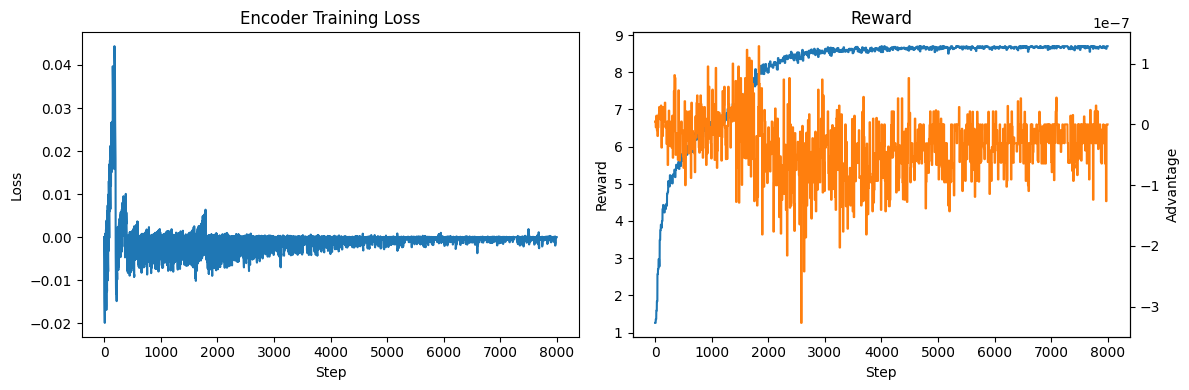

In [61]:
loss, advantage, reward = run_policy_gradient(prompts=grpo_prompt, vocab_size = vocab_size, 
                                   advantage_fn=normalized_advantage, loss_fn=clipped_loss, 
                                   kl_penalty=0.01, epochs=800)

plot_run_and_reward(loss, advantage, reward)

### Clipped Run, Max_Min Rewards, KL
Now, just to experiment we'll tweak a few parameters.  We'll switch to using the tournament style min/max advantage that only keeps the top value and negatives. We'll also unclip the loss, and turn off KL penalty.  In real life this would mean our model can drift far from the initial weights.  What we see is a faster growth to the limit, but then some very bad samples that seem to drift the model and pull it lower. This shows some of the dangers of removing the KL penalty and tweaking the loss allowing the model to drift more. 

epoch: 100%|█████████████████████████████████████████████████████████████| 800/800 [00:04<00:00, 188.17it/s]


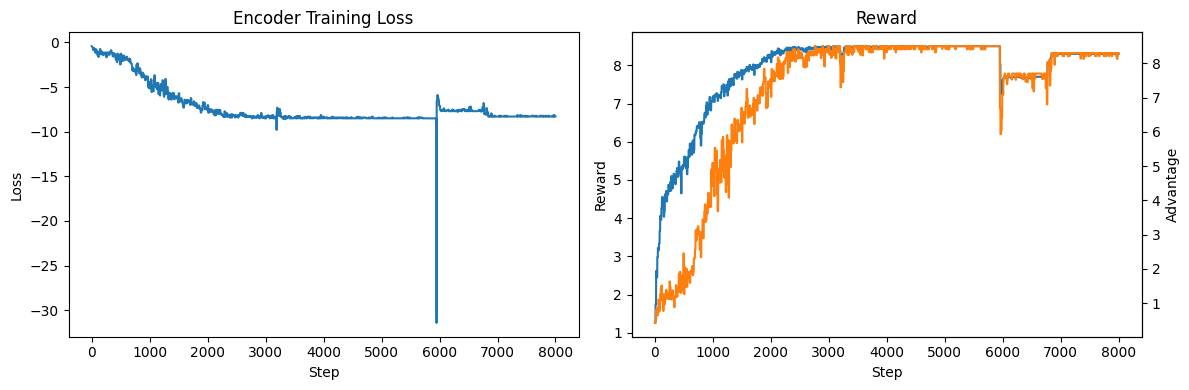

In [62]:
mm_loss, mm_advantage, mm_reward = run_policy_gradient(prompts=grpo_prompt, vocab_size = vocab_size, 
                                   advantage_fn=max_min_advantage, loss_fn=unclipped_loss, 
                                   kl_penalty=0.00, epochs=800)

plot_run_and_reward(mm_loss, mm_advantage, mm_reward)

## Conclusion 
Overall we've walked through what a GRPO loop might look like on a simple model built to order numbers. You can image that model being replaced with an LLM like GPT and then having a task like completing different math problems and rewarding based on how close it gets, or rewarding based on how many intermediate steps are correct.  With GRPO though you can see how there's a number of places to further customize, whether it's the reward, the advantage, the loss, and/or the KL penalty.  All of these require careful fine-tuning and experimentation as they can cause model collapse quickly. Models are very attune to reward hacking so the battle is to fight against it and drive model improvements. 